In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import joblib

In [5]:
df = pd.read_csv("../data/final/feature_engineered_stock_data.csv")

print(df.shape)

df.head()

(418075, 49)


,Date,Close,High,Low,Open,Volume,Ticker,Daily_Return,MA5,MA10,...,NIFTY_Close,NIFTY_Return,Relative_Strength,Bank_Relative_Strength,Volume_Ratio,Prev_Close,Gap_Percentage,ATR_Percentage,Bull_Market,Target_Signal_Balanced
0,2008-04-02,621.754211,628.870167,618.566878,620.123469,299209.0,ACC,0.017097,615.431458,602.463446,...,4754.200195,0.003091,-0.292012,-2.473786,0.618517,611.302795,1.442930,4.385541,0,SELL
1,2008-04-03,612.933411,621.161184,604.149660,613.748759,586458.0,ACC,-0.014187,615.987378,607.448297,...,4771.600098,0.003660,-0.380177,0.378572,1.189842,621.754211,-1.287559,4.336049,0,HOLD
2,2008-04-04,615.861389,637.357424,608.634274,637.357424,388972.0,ACC,0.004777,614.845886,611.421350,...,4647.000000,-0.026113,2.616062,2.983536,0.854275,612.933411,3.984774,4.340324,0,HOLD
3,2008-04-07,617.158508,622.643721,608.560113,611.525083,486842.0,ACC,0.002106,615.802063,613.493109,...,4761.200195,0.024575,-2.455397,-4.386639,1.065793,615.861389,-0.704104,4.184831,0,SELL
4,2008-04-08,611.784546,620.420040,600.480597,620.420040,483884.0,ACC,-0.008708,615.898413,614.082391,...,4709.649902,-0.010827,1.074009,-0.452192,1.110288,617.158508,0.528476,4.152850,0,SELL


In [6]:
feature_columns = [

    "Close",
    "High",
    "Low",
    "Open",
    "Volume",

    "Daily_Return",

    "MA5",
    "MA10",
    "MA20",
    "MA50",

    "EMA20",
    "EMA12",
    "EMA26",

    "RSI",

    "MACD",
    "Signal_Line",
    "MACD_Histogram",

    "Upper_Band",
    "Lower_Band",

    "Volatility",

    "Lag1",
    "Lag2",
    "Lag3",

    "ATR",
    "ADX",
    "OBV",
    "Stochastic",
    "CCI",

    "Price_vs_MA20",
    "EMA_Diff",
    "BB_Width",

    "NIFTY_Close",
    "NIFTY_Return",

    "India_VIX",

    "BankNIFTY_Close",
    "BankNIFTY_Return",

    "Relative_Strength",
    "Bank_Relative_Strength",

    "Volume_Ratio",
    "Gap_Percentage",
    "ATR_Percentage",
    "Bull_Market"
]

In [7]:
X = df[feature_columns]

y = df["Target_Signal"]

In [8]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print(label_encoder.classes_)

['BUY' 'HOLD' 'SELL']


In [9]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(

    X,
    y_encoded,

    test_size=0.20,

    shuffle=False

)

print(X_train_cls.shape)
print(X_test_cls.shape)

(334460, 42)
(83615, 42)


In [10]:
classification_results = pd.DataFrame(

    columns=[

        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"

    ]

)

In [27]:
baseline = DummyClassifier(strategy="most_frequent")

baseline.fit(X_train_cls, y_train_cls)

baseline_pred = baseline.predict(X_test_cls)

classification_results.loc[len(classification_results)] = [

    "Baseline",

    accuracy_score(y_test_cls, baseline_pred),

    precision_score(
        y_test_cls,
        baseline_pred,
        average="weighted",
        zero_division=0
    ),

    recall_score(
        y_test_cls,
        baseline_pred,
        average="weighted"
    ),

    f1_score(
        y_test_cls,
        baseline_pred,
        average="weighted"
    )

]

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Train
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_cls, y_train_cls)

# Predict
lr_pred = lr.predict(X_test_cls)

# Metrics
accuracy = accuracy_score(y_test_cls, lr_pred)
precision = precision_score(y_test_cls, lr_pred, average="weighted")
recall = recall_score(y_test_cls, lr_pred, average="weighted")
f1 = f1_score(y_test_cls, lr_pred, average="weighted")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print(classification_report(
    y_test_cls,
    lr_pred,
    target_names=label_encoder.classes_
))

classification_results.loc[len(classification_results)] = [
    "Logistic Regression",
    accuracy,
    precision,
    recall,
    f1
]

Accuracy : 0.3957663098726305
Precision: 0.28164761718458386
Recall   : 0.3957663098726305
F1 Score : 0.22751975659950155
              precision    recall  f1-score   support

         BUY       0.41      0.01      0.01     25273
        HOLD       0.40      1.00      0.57     33030
        SELL       0.00      0.00      0.00     25312

    accuracy                           0.40     83615
   macro avg       0.27      0.33      0.19     83615
weighted avg       0.28      0.40      0.23     83615



In [30]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train_cls, y_train_cls)

dt_pred = dt.predict(X_test_cls)

accuracy = accuracy_score(y_test_cls, dt_pred)
precision = precision_score(y_test_cls, dt_pred, average="weighted")
recall = recall_score(y_test_cls, dt_pred, average="weighted")
f1 = f1_score(y_test_cls, dt_pred, average="weighted")

print(classification_report(
    y_test_cls,
    dt_pred,
    target_names=label_encoder.classes_
))

classification_results.loc[len(classification_results)] = [
    "Decision Tree",
    accuracy,
    precision,
    recall,
    f1
]

              precision    recall  f1-score   support

         BUY       0.35      0.35      0.35     25273
        HOLD       0.42      0.39      0.41     33030
        SELL       0.35      0.38      0.37     25312

    accuracy                           0.38     83615
   macro avg       0.37      0.38      0.37     83615
weighted avg       0.38      0.38      0.38     83615



In [31]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=1
)

rf.fit(X_train_cls, y_train_cls)

rf_pred = rf.predict(X_test_cls)

accuracy = accuracy_score(y_test_cls, rf_pred)
precision = precision_score(y_test_cls, rf_pred, average="weighted")
recall = recall_score(y_test_cls, rf_pred, average="weighted")
f1 = f1_score(y_test_cls, rf_pred, average="weighted")

print(classification_report(
    y_test_cls,
    rf_pred,
    target_names=label_encoder.classes_
))

classification_results.loc[len(classification_results)] = [
    "Random Forest",
    accuracy,
    precision,
    recall,
    f1
]

              precision    recall  f1-score   support

         BUY       0.47      0.25      0.33     25273
        HOLD       0.46      0.75      0.57     33030
        SELL       0.46      0.29      0.36     25312

    accuracy                           0.46     83615
   macro avg       0.46      0.43      0.42     83615
weighted avg       0.46      0.46      0.43     83615



In [32]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective="multi:softmax",
    num_class=3,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train_cls, y_train_cls)

xgb_pred = xgb.predict(X_test_cls)

accuracy = accuracy_score(y_test_cls, xgb_pred)
precision = precision_score(y_test_cls, xgb_pred, average="weighted")
recall = recall_score(y_test_cls, xgb_pred, average="weighted")
f1 = f1_score(y_test_cls, xgb_pred, average="weighted")

print(classification_report(
    y_test_cls,
    xgb_pred,
    target_names=label_encoder.classes_
))

classification_results.loc[len(classification_results)] = [
    "XGBoost",
    accuracy,
    precision,
    recall,
    f1
]

              precision    recall  f1-score   support

         BUY       0.51      0.26      0.34     25273
        HOLD       0.46      0.73      0.57     33030
        SELL       0.49      0.37      0.42     25312

    accuracy                           0.48     83615
   macro avg       0.49      0.45      0.44     83615
weighted avg       0.49      0.48      0.45     83615



In [33]:
from catboost import CatBoostClassifier

cat = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    random_seed=42,
    verbose=False
)

cat.fit(X_train_cls, y_train_cls)

cat_pred = cat.predict(X_test_cls)

accuracy = accuracy_score(y_test_cls, cat_pred)
precision = precision_score(y_test_cls, cat_pred, average="weighted")
recall = recall_score(y_test_cls, cat_pred, average="weighted")
f1 = f1_score(y_test_cls, cat_pred, average="weighted")

print(classification_report(
    y_test_cls,
    cat_pred,
    target_names=label_encoder.classes_
))

classification_results.loc[len(classification_results)] = [
    "CatBoost",
    accuracy,
    precision,
    recall,
    f1
]

              precision    recall  f1-score   support

         BUY       0.46      0.25      0.33     25273
        HOLD       0.46      0.74      0.57     33030
        SELL       0.45      0.29      0.36     25312

    accuracy                           0.46     83615
   macro avg       0.46      0.43      0.42     83615
weighted avg       0.46      0.46      0.43     83615



In [34]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    objective="multiclass",
    num_class=3,
    n_estimators=500,
    learning_rate=0.05,
    random_state=42
)

lgbm.fit(X_train_cls, y_train_cls)

lgbm_pred = lgbm.predict(X_test_cls)

accuracy = accuracy_score(y_test_cls, lgbm_pred)
precision = precision_score(y_test_cls, lgbm_pred, average="weighted")
recall = recall_score(y_test_cls, lgbm_pred, average="weighted")
f1 = f1_score(y_test_cls, lgbm_pred, average="weighted")

print(classification_report(
    y_test_cls,
    lgbm_pred,
    target_names=label_encoder.classes_
))

classification_results.loc[len(classification_results)] = [
    "LightGBM",
    accuracy,
    precision,
    recall,
    f1
]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.048143 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10457
[LightGBM] [Info] Number of data points in the train set: 334460, number of used features: 42
[LightGBM] [Info] Start training from score -1.205848
[LightGBM] [Info] Start training from score -0.913194
[LightGBM] [Info] Start training from score -1.206238
              precision    recall  f1-score   support

         BUY       0.52      0.31      0.39     25273
        HOLD       0.48      0.70      0.57     33030
        SELL       0.52      0.43      0.47     25312

    accuracy                           0.50     83615
   macro avg       0.51      0.48      0.48     83615
weighted avg       0.51      0.50      0.48     83615



In [25]:
classification_results = classification_results.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

classification_results

,Model,Accuracy,Precision,Recall,F1 Score


In [23]:
classification_results = pd.DataFrame(
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

In [24]:
classification_results = classification_results.iloc[0:0]

In [35]:
classification_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline,0.395025,0.156045,0.395025,0.223716
1,Logistic Regression,0.395766,0.281648,0.395766,0.227520
2,Decision Tree,0.377205,0.379406,0.377205,0.377854
3,Random Forest,0.459595,0.462337,0.459595,0.430352
4,XGBoost,0.477199,0.485328,0.477199,0.454704
5,CatBoost,0.458147,0.456746,0.458147,0.430672
6,LightGBM,0.497746,0.505992,0.497746,0.484273


In [41]:
!pip install optuna


[notice] A new release of pip is available: 26.1.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [42]:
import optuna
import pandas as pd
import numpy as np

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [36]:
from sklearn.model_selection import train_test_split

X = df[feature_columns]
y = y_encoded

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

In [37]:
from sklearn.model_selection import train_test_split

X = df[feature_columns]
y = y_encoded

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

In [38]:
X_train_opt, X_valid, y_train_opt, y_valid = train_test_split(
    X_train_cls,
    y_train_cls,
    test_size=0.2,
    shuffle=False
)

print(X_train_opt.shape)
print(X_valid.shape)

(267568, 42)
(66892, 42)


In [39]:
def objective(trial):

    params = {

        "objective": "multi:softprob",

        "num_class": 3,

        "eval_metric": "mlogloss",

        "random_state": 42,

        "n_jobs": 4,

        "n_estimators": trial.suggest_int(
            "n_estimators",
            300,
            800
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.1,
            log=True
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            4,
            10
        ),

        "min_child_weight": trial.suggest_int(
            "min_child_weight",
            1,
            10
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.7,
            1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.7,
            1.0
        ),

        "gamma": trial.suggest_float(
            "gamma",
            0,
            5
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            0,
            5
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            0,
            5
        )

    }

    model = XGBClassifier(**params)

    model.fit(
        X_train_opt,
        y_train_opt
    )

    pred = model.predict(X_valid)

    return accuracy_score(
        y_valid,
        pred
    )

In [43]:
study = optuna.create_study(
    direction="maximize"
)

study.optimize(
    objective,
    n_trials=50
)

[I 2026-08-06 18:48:50,695] A new study created in memory with name: no-name-5143b1fa-1cb2-4f63-90b7-a2b093714d17
[I 2026-08-06 18:49:56,769] Trial 0 finished with value: 0.4690695449381092 and parameters: {'n_estimators': 686, 'learning_rate': 0.013433364335867835, 'max_depth': 5, 'min_child_weight': 3, 'subsample': 0.9964264360453282, 'colsample_bytree': 0.9171576636452918, 'gamma': 2.8132396846423458, 'reg_alpha': 1.288030307047895, 'reg_lambda': 3.365513525069743}. Best is trial 0 with value: 0.4690695449381092.
[I 2026-08-06 18:50:42,606] Trial 1 finished with value: 0.45275967230760034 and parameters: {'n_estimators': 547, 'learning_rate': 0.010959516023034195, 'max_depth': 4, 'min_child_weight': 1, 'subsample': 0.9888433846329387, 'colsample_bytree': 0.8139667830152142, 'gamma': 1.4736411266052918, 'reg_alpha': 0.05292677403348822, 'reg_lambda': 3.1135269119163373}. Best is trial 0 with value: 0.4690695449381092.
[I 2026-08-06 18:51:46,787] Trial 2 finished with value: 0.5043502

In [44]:
xgb_best_params = study.best_params.copy()

print(xgb_best_params)

{'n_estimators': 426, 'learning_rate': 0.038557294234695685, 'max_depth': 10, 'min_child_weight': 9, 'subsample': 0.7868172030876518, 'colsample_bytree': 0.7949398142359931, 'gamma': 0.756570016302506, 'reg_alpha': 3.0858745836228625, 'reg_lambda': 0.9915135250148421}


In [45]:
best_xgb = XGBClassifier(

    objective="multi:softprob",

    num_class=3,

    eval_metric="mlogloss",

    random_state=42,

    n_jobs=4,

    **xgb_best_params

)

best_xgb.fit(
    X_train_cls,
    y_train_cls
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7949398142359931
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import lo

In [46]:
pred = best_xgb.predict(
    X_test_cls
)

In [47]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(y_test_cls, pred)

precision = precision_score(
    y_test_cls,
    pred,
    average="weighted"
)

recall = recall_score(
    y_test_cls,
    pred,
    average="weighted"
)

f1 = f1_score(
    y_test_cls,
    pred,
    average="weighted"
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print()

print(
    classification_report(
        y_test_cls,
        pred,
        target_names=label_encoder.classes_
    )
)

Accuracy : 0.5206482090533995
Precision: 0.5293724679270505
Recall   : 0.5206482090533995
F1 Score : 0.5137876510463049

              precision    recall  f1-score   support

         BUY       0.55      0.37      0.44     25273
        HOLD       0.49      0.66      0.56     33030
        SELL       0.56      0.49      0.52     25312

    accuracy                           0.52     83615
   macro avg       0.53      0.51      0.51     83615
weighted avg       0.53      0.52      0.51     83615



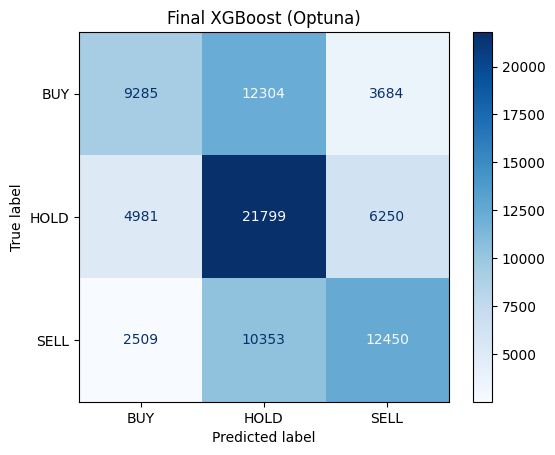

In [48]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test_cls,
    pred,
    display_labels=label_encoder.classes_,
    cmap="Blues",
    values_format="d"
)

plt.title("Final XGBoost (Optuna)")
plt.grid(False)
plt.show()

In [49]:
importance = pd.DataFrame({

    "Feature": feature_columns,

    "Importance": best_xgb.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
40,ATR_Percentage,0.077468
35,BankNIFTY_Return,0.038876
32,NIFTY_Return,0.038852
31,NIFTY_Close,0.038114
33,India_VIX,0.038078
34,BankNIFTY_Close,0.036968
41,Bull_Market,0.034624
36,Relative_Strength,0.032809
37,Bank_Relative_Strength,0.031767
19,Volatility,0.027012


In [50]:
import joblib

joblib.dump(
    best_xgb,
    "../models/best_xgboost_optuna.pkl"
)

joblib.dump(
    label_encoder,
    "../models/label_encoder.pkl"
)

joblib.dump(
    xgb_best_params,
    "../models/xgb_best_params.pkl"
)

print("Everything saved successfully!")

Everything saved successfully!
